# Large Scope Question 1 Notebook

### Tools:
Claude was used for error correction and code restructuring.
  
### Folder Structure Expected
Folders follow the O\*NET naming convention e.g. `db_16_0_2011`, `db_17_0_2012`.
Each folder contains `Occupation.txt` and `Skills.txt`.
```
Dataset2011-2025/
  db_16_0_2011/
    Occupation Data.txt
    Skills.txt
  db_22_0_2017/
    Occupation Data.xlsx
    Skills.xlsx
  ...
  db_30_1_2025/
    Occupation Data.txt
    Skills.txt
```

### 1. Imports

In [ ]:
import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### 2. Configuration

In [7]:
# Pearson correlation cutoff — same as main pipeline (-1 to 1)
THRESHOLD  = 0.95          
# Select only IMPORTANCE values
SCALE      = "IM"
# Root folder containing the db_XX_X_YYYY subfolders
DATA_DIR = "." 

# The two years to compare for identifying recession-sensitive occupations
PRE_DOWNTURN  = 2019
POST_DOWNTURN = 2021

# Minimum edge loss fraction to qualify as recession-sensitive
EDGE_LOSS_THRESHOLD = 0.50

### 3. Core Pipeline Functions
These are the same functions from the main notebook, wrapped so they can be called on any year's data.

In [8]:
def extract_year(folder_name):
    """
    Extract the 4-digit year from a folder name like db_16_0_2011 or db_30_1_2025. Returns an integer year, or None if no year found.
    """
    parts = folder_name.split("_")
    for part in reversed(parts):
        if part.isdigit() and len(part) == 4:
            return int(part)
    return None


# The exact 35 Element IDs used in the 2025 O*NET release.
# All yearly networks are restricted to these same skills for consistency.
SKILL_IDS = [
    '2.A.1.a', 
    '2.A.1.b', 
    '2.A.1.c', 
    '2.A.1.d', 
    '2.A.1.e', 
    '2.A.1.f',
    '2.A.2.a', 
    '2.A.2.b', 
    '2.A.2.c', 
    '2.A.2.d',
    '2.B.1.a', 
    '2.B.1.b', 
    '2.B.1.c', 
    '2.B.1.d', 
    '2.B.1.e', 
    '2.B.1.f',
    '2.B.2.i',
    '2.B.3.a', 
    '2.B.3.b', 
    '2.B.3.c', 
    '2.B.3.d', 
    '2.B.3.e',
    '2.B.3.g', 
    '2.B.3.h', 
    '2.B.3.j', 
    '2.B.3.k', 
    '2.B.3.l', 
    '2.B.3.m',
    '2.B.4.e', 
    '2.B.4.g', 
    '2.B.4.h',
    '2.B.5.a', 
    '2.B.5.b', 
    '2.B.5.c', 
    '2.B.5.d'
]

def read_file(folder, filename_base):
    """
    Load a txt data file from a folder.
    """
    txt_path = os.path.join(folder, filename_base + ".txt")
    if not os.path.exists(txt_path):
        raise FileNotFoundError(f"Could not find '{filename_base}.txt' in {folder}")
    df = pd.read_csv(txt_path, delimiter="\t", low_memory=False)
    df.columns = df.columns.str.strip()
    return df


def load_data(folder):
    """
    Load occupation and skills data from a folder.
    """
    occ    = read_file(folder, "Occupation Data")[["O*NET-SOC Code", "Title"]]
    skills = read_file(folder, "Skills")[["O*NET-SOC Code", "Element ID", "Scale ID", "Data Value"]]
    return occ, skills


def build_matrix(skills):
    """
    Filter to IM scale and the fixed 35 skill IDs, then pivot into occupation x skill matrix.
    """
    filtered = skills[(skills["Scale ID"] == SCALE) & (skills["Element ID"].isin(SKILL_IDS))]
    matrix = filtered.pivot_table(
        index="O*NET-SOC Code",
        columns="Element ID",
        values="Data Value",
        aggfunc="mean"
    ).fillna(0)
    # Reindex to ensure all years use exactly the same 35 skills in the same order
    matrix = matrix.reindex(columns=SKILL_IDS, fill_value=0)
    return matrix


def compute_edges(matrix):
    """
    Compute pairwise Pearson correlations and keep pairs above threshold.
    """
    corr_matrix = matrix.T.corr()
    codes = corr_matrix.index.tolist()
    edges = []
    for i in range(len(codes)):
        for j in range(i + 1, len(codes)):
            corr = corr_matrix.iloc[i, j]
            if corr >= THRESHOLD:
                edges.append({"Source": codes[i], "Target": codes[j], "Weight": round(float(corr), 4)})
    return pd.DataFrame(edges)


def build_graph(edges_df):
    """
    Build a NetworkX graph from the edges dataframe.
    """
    G = nx.Graph()
    for _, row in edges_df.iterrows():
        G.add_edge(row["Source"], row["Target"], weight=row["Weight"])
    return G


def build_network_for_folder(folder_path):
    """
    Full pipeline for a single year folder. Returns (graph, edges_df, occ_df).
    """
    occ, skills  = load_data(folder_path)
    matrix       = build_matrix(skills)
    edges_df     = compute_edges(matrix)
    
    # Only keep occupations that appear in at least one edge — matches original pipeline
    if len(edges_df) > 0:
        connected = set(edges_df["Source"]).union(set(edges_df["Target"]))
        G = build_graph(edges_df)
        G.remove_nodes_from([n for n in G.nodes() if n not in connected])
    else:
        G = nx.Graph()
    
    return G, edges_df, occ


def run_targeted_removal(G_original, nodes_to_remove):
    """
    Remove recession-sensitive nodes one by one and track LCC size at each step.
    Returns fraction of nodes removed and corresponding LCC fractions.
    """
    G = G_original.copy()
    total_nodes = G.number_of_nodes()
    fractions_removed = [0]
    lcc_fractions     = [lcc_fraction(G)]

    for i, node in enumerate(nodes_to_remove):
        if node in G:
            G.remove_node(node)
        fractions_removed.append((i + 1) / total_nodes)
        lcc_fractions.append(lcc_fraction(G))

    return fractions_removed, lcc_fractions


def run_random_removal(G_original, n_removals, n_trials=100):
    """
    Randomly remove the same number of nodes as the targeted simulation.
    Average over n_trials runs to produce a smooth baseline curve.
    """
    total_nodes = G_original.number_of_nodes()
    all_lcc = np.zeros((n_trials, n_removals + 1))

    for trial in range(n_trials):
        G = G_original.copy()
        nodes = list(G.nodes())
        np.random.shuffle(nodes)
        random_order = nodes[:n_removals]

        all_lcc[trial, 0] = lcc_fraction(G)
        for i, node in enumerate(random_order):
            if node in G:
                G.remove_node(node)
            all_lcc[trial, i + 1] = lcc_fraction(G)

    avg_lcc = all_lcc.mean(axis=0)
    fractions_removed = [i / total_nodes for i in range(n_removals + 1)]
    return fractions_removed, avg_lcc.tolist()

def lcc_fraction(G):
    """
    Return the LCC size as a fraction of total nodes.
    Used to track how connected the network remains after each removal step.
    """
    if G.number_of_nodes() == 0:
        return 0
    # nx.connected_components: https://networkx.org/documentation/stable/reference/algorithms/component.html
    lcc = max(nx.connected_components(G), key=len)
    return len(lcc) / G.number_of_nodes()


def run_targeted_removal(G_original, nodes_to_remove):
    """
    Remove recession-sensitive nodes one by one and track LCC size at each step.
    Returns lists of fraction removed and corresponding LCC fractions.
    """
    G = G_original.copy()
    total_nodes = G.number_of_nodes()
    fractions_removed = [0]
    lcc_fractions     = [lcc_fraction(G)]

    for i, node in enumerate(nodes_to_remove):
        if node in G:
            G.remove_node(node)
        fractions_removed.append((i + 1) / total_nodes)
        lcc_fractions.append(lcc_fraction(G))

    return fractions_removed, lcc_fractions


def run_random_removal(G_original, n_removals, n_trials=100):
    """
    Randomly remove the same number of nodes as the targeted simulation.
    Average over n_trials runs to produce a smooth baseline curve.
    This tells us whether recession-sensitive occupations cause more damage than random removal.
    """
    total_nodes = G_original.number_of_nodes()
    all_lcc = np.zeros((n_trials, n_removals + 1))

    for trial in range(n_trials):
        G = G_original.copy()
        nodes = list(G.nodes())
        np.random.shuffle(nodes)
        random_order = nodes[:n_removals]

        all_lcc[trial, 0] = lcc_fraction(G)
        for i, node in enumerate(random_order):
            if node in G:
                G.remove_node(node)
            all_lcc[trial, i + 1] = lcc_fraction(G)

    avg_lcc = all_lcc.mean(axis=0)
    fractions_removed = [i / total_nodes for i in range(n_removals + 1)]
    return fractions_removed, avg_lcc.tolist()


def run_targeted_removal_full(G_original, nodes_to_remove):
    """
    Extends run_targeted_removal by also tracking connected components
    and isolated nodes at each step, allowing us to measure skill island formation.
    """
    G = G_original.copy()
    total_nodes = G.number_of_nodes()

    # Record the starting state before any removals
    records = [{
        'fraction_removed': 0,
        'lcc_fraction':     lcc_fraction(G),
        'n_components':     nx.number_connected_components(G),
        # Isolated nodes are those with degree 0 — completely disconnected skill islands
        'isolated_nodes':   sum(1 for n in G.nodes() if G.degree(n) == 0)
    }]

    # Remove each recession-sensitive node one by one and record the network state
    for i, node in enumerate(nodes_to_remove):
        if node in G:
            G.remove_node(node)
        records.append({
            'fraction_removed': (i + 1) / total_nodes,
            'lcc_fraction':     lcc_fraction(G),
            'n_components':     nx.number_connected_components(G),
            'isolated_nodes':   sum(1 for n in G.nodes() if G.degree(n) == 0)
        })

    return pd.DataFrame(records)


### 4. Network Statistics Function

In [9]:
def compute_stats(G, year):
    """
    Compute core network statistics for a given graph. Uses the Largest Connected Component (LCC) for path length and clustering.
    """
    lcc_nodes = max(nx.connected_components(G), key=len)
    LCC       = G.subgraph(lcc_nodes)

    num_nodes      = G.number_of_nodes()
    num_edges      = G.number_of_edges()
    num_components = nx.number_connected_components(G)
    lcc_size       = len(lcc_nodes)
    avg_degree     = round(sum(dict(G.degree()).values()) / num_nodes, 3) if num_nodes > 0 else 0
    # nx.average_clustering: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.average_clustering.html
    avg_clustering = round(nx.average_clustering(G), 4)
    # nx.average_shortest_path_length: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.average_shortest_path_length.html
    avg_path_len   = round(nx.average_shortest_path_length(LCC), 4)

    return {
        "Year":           year,
        "Nodes":          num_nodes,
        "Edges":          num_edges,
        "Components":     num_components,
        "LCC Size":       lcc_size,
        "Avg Degree":     avg_degree,
        "Avg Clustering": avg_clustering,
        "Avg Path Length":avg_path_len
    }

### 5. Build All Yearly Networks
This cell loops through every year folder, builds the network, and records statistics.
This will take a few minutes to generate results.

In [10]:
# Discover all year folders automatically and extract their year
raw_folders = sorted([f for f in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, f))])

# Build a list of (year, folder_name) pairs, skipping anything without a valid year
year_folders = []
for f in raw_folders:
    year = extract_year(f)
    if year:
        year_folders.append((year, f))
year_folders.sort(key=lambda x: x[0])

print(f"Found {len(year_folders)} release(s):")
for y, f in year_folders:
    print(f"  {y}  →  {f}")

# One stats dict per year
all_stats  = [] 
# NetworkX graph keyed by integer year
all_graphs = {}
# Occupation dataframe keyed by integer year
all_occs   = {}   

# Loop through each year, build the network, compute stats, and store results
for year, folder_name in year_folders:
    folder_path = os.path.join(DATA_DIR, folder_name)
    print(f"Processing {year} ({folder_name})...", end=" ")
    G, edges_df, occ = build_network_for_folder(folder_path)
    all_graphs[year] = G
    all_occs[year]   = occ
    stats = compute_stats(G, year)
    all_stats.append(stats)
    print(f"Done — {stats['Nodes']} nodes, {stats['Edges']} edges")

# Combine all yearly stats into a single dataframe
stats_df = pd.DataFrame(all_stats)
stats_df

Found 15 release(s):
  2011  →  db_16_0_2011
  2012  →  db_17_0_2012
  2013  →  db_18_0_2013
  2014  →  db_19_0_2014
  2015  →  db_20_0_2015
  2016  →  db_21_0_2016
  2017  →  db_22_0_2017
  2018  →  db_23_0_2018
  2019  →  db_24_0_2019
  2020  →  db_25_0_2020
  2021  →  db_26_0_2021
  2022  →  db_27_0_2022
  2023  →  db_28_0_2023
  2024  →  db_29_0_2024
  2025  →  db_30_1_2025
Processing 2011 (db_16_0_2011)... Done — 470 nodes, 2224 edges
Processing 2012 (db_17_0_2012)... Done — 499 nodes, 2589 edges
Processing 2013 (db_18_0_2013)... Done — 502 nodes, 2675 edges
Processing 2014 (db_19_0_2014)... Done — 513 nodes, 2847 edges
Processing 2015 (db_20_0_2015)... Done — 529 nodes, 3003 edges
Processing 2016 (db_21_0_2016)... Done — 530 nodes, 3094 edges
Processing 2017 (db_22_0_2017)... Done — 536 nodes, 3157 edges
Processing 2018 (db_23_0_2018)... Done — 543 nodes, 3271 edges
Processing 2019 (db_24_0_2019)... Done — 543 nodes, 3261 edges
Processing 2020 (db_25_0_2020)... Done — 547 nodes, 

,Year,Nodes,Edges,Components,LCC Size,Avg Degree,Avg Clustering,Avg Path Length
0,2011,470,2224,29,377,9.464,0.3654,4.1511
1,2012,499,2589,28,404,10.377,0.3778,3.9580
2,2013,502,2675,28,415,10.657,0.3778,3.9556
3,2014,513,2847,27,431,11.099,0.3855,3.9353
4,2015,529,3003,24,451,11.353,0.3834,3.9696
5,2016,530,3094,25,454,11.675,0.3937,3.9214
6,2017,536,3157,23,466,11.780,0.3918,3.9542
7,2018,543,3271,24,465,12.048,0.3866,3.8661
8,2019,543,3261,26,469,12.011,0.3927,3.8598
9,2020,547,3246,29,467,11.868,0.3786,3.8583


### 6. Plot Statistics Over Time

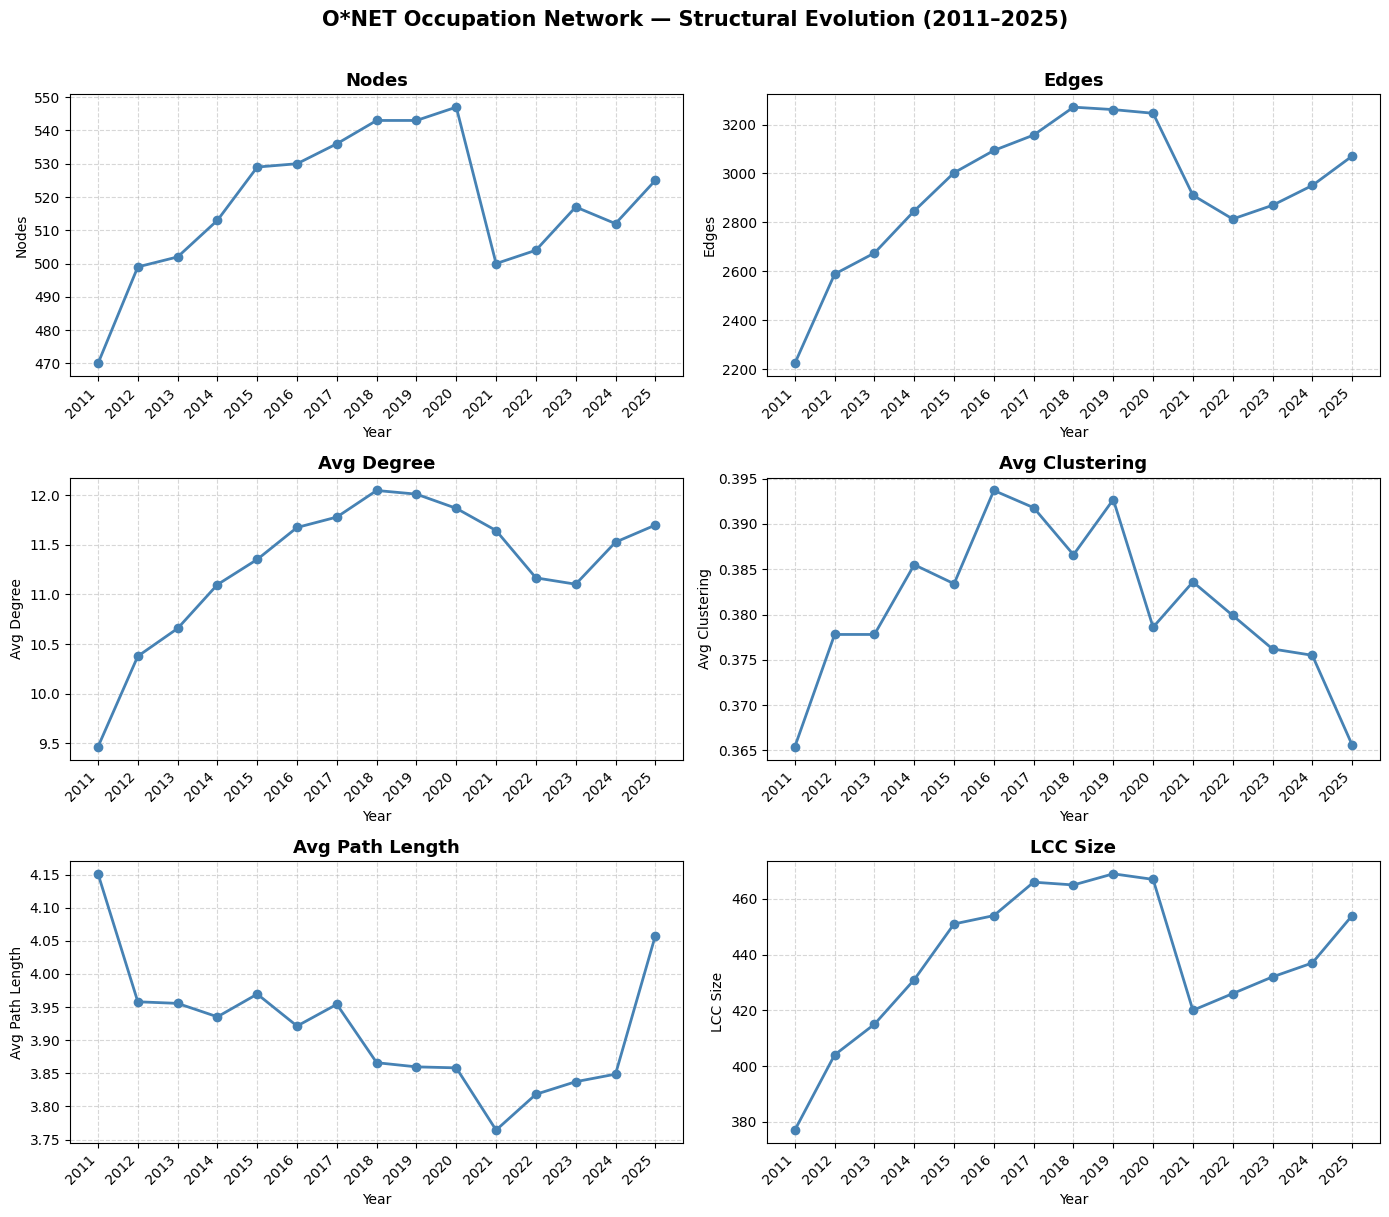

In [11]:
# Define the six metrics to plot
metrics = ["Nodes", "Edges", "Avg Degree", "Avg Clustering", "Avg Path Length", "LCC Size"]
# Create a 3x2 grid of subplots, one for each metric
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    # Plot the metric over time with year on x-axis
    axes[i].plot(stats_df["Year"], stats_df[metric], marker="o", color="steelblue", linewidth=2)
    axes[i].set_title(metric, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel(metric)
    axes[i].grid(True, linestyle="--", alpha=0.5)
    # Show every year on the x-axis and rotate labels
    axes[i].set_xticks(stats_df["Year"])
    axes[i].set_xticklabels(stats_df["Year"], rotation=45, ha="right")
    
# Add title
plt.suptitle("O*NET Occupation Network — Structural Evolution (2011–2025)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

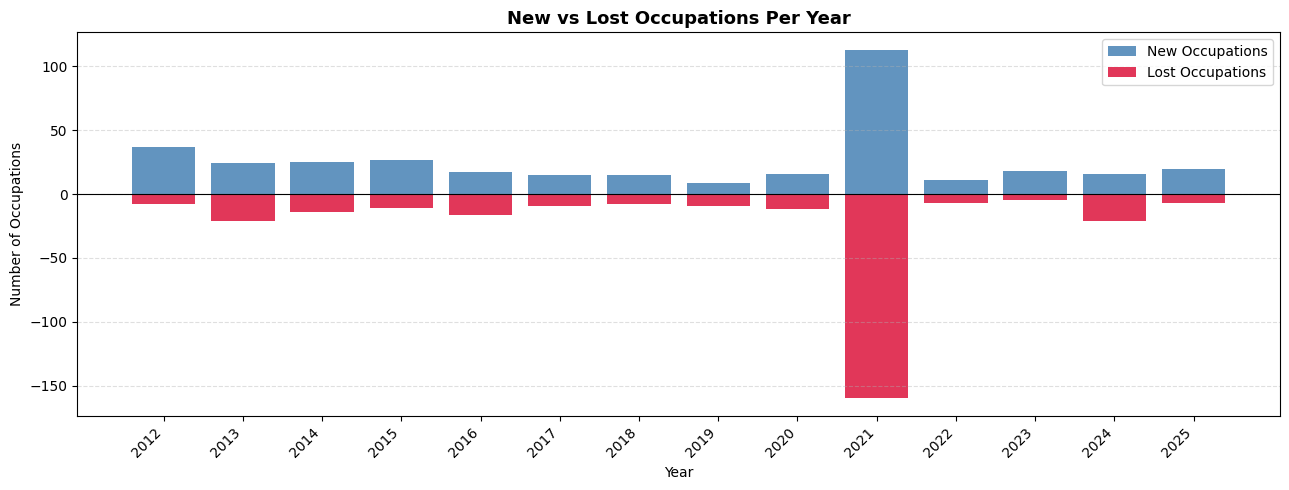

In [12]:
# New vs Lost Occupations per year
# For each consecutive year pair, compare which occupation nodes entered or left the network
years_sorted = sorted(all_graphs.keys())
new_counts  = []
lost_counts = []
# Start from the 2nd year since we need a previous year to compare against
change_years = years_sorted[1:]

for i in range(1, len(years_sorted)):
    prev_year = years_sorted[i - 1]
    curr_year = years_sorted[i]
    prev_nodes = set(all_graphs[prev_year].nodes())
    curr_nodes = set(all_graphs[curr_year].nodes())

    # New = occupations in current year that were not in the previous year
    new_counts.append(len(curr_nodes - prev_nodes))
    # Lost = occupations in previous year that are no longer in the current year
    lost_counts.append(len(prev_nodes - curr_nodes))

# Plot new occupations as positive bars and lost as negative bars
fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(change_years))
bars_new  = ax.bar(x, new_counts,  color="steelblue", label="New Occupations",  alpha=0.85)
bars_lost = ax.bar(x, [-v for v in lost_counts], color="crimson", label="Lost Occupations", alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(change_years, rotation=45, ha="right")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Occupations")
ax.set_title("New vs Lost Occupations Per Year", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

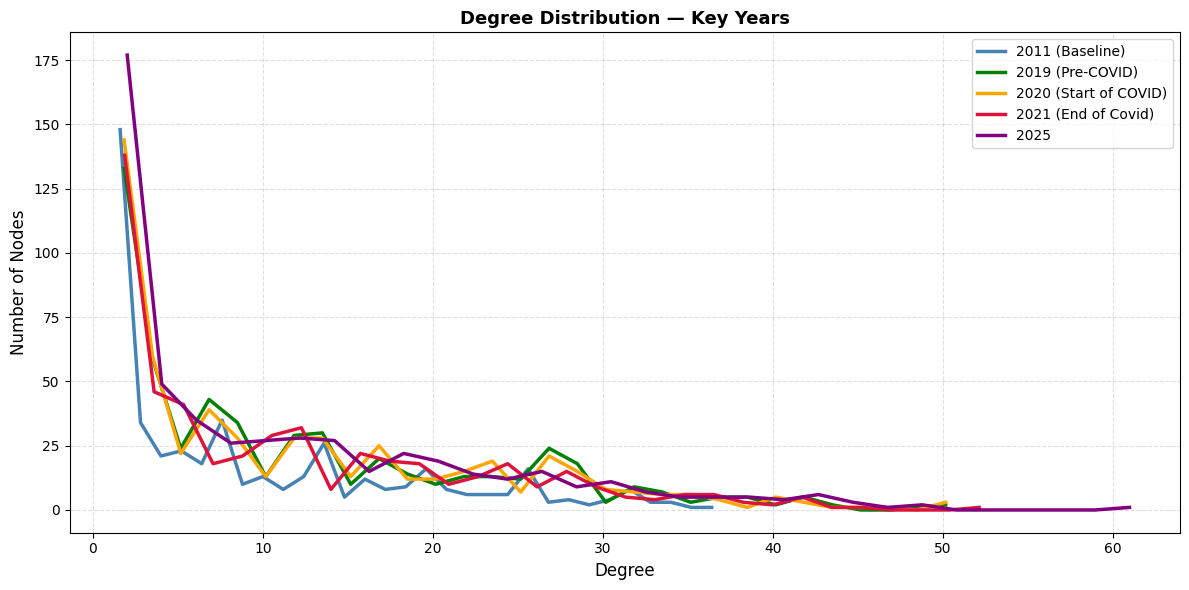

In [13]:
# Degree distribution comparison across five key years
# Shows how the connectivity pattern of occupations changed over time
key_years  = [2011, 2019, 2020, 2021, 2025]
colors     = ["steelblue", "green", "orange", "crimson", "purple"]
labels     = ["2011 (Baseline)", "2019 (Pre-COVID)", "2020 (Start of COVID)", "2021 (End of Covid)", "2025"]

fig, ax = plt.subplots(figsize=(12, 6))

for year, color, label in zip(key_years, colors, labels):
    degrees = np.array([d for _, d in all_graphs[year].degree()])
    # Use histogram bins to count nodes at each degree level
    counts, bin_edges = np.histogram(degrees, bins=30)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(bin_centers, counts, color=color, linewidth=2.5, label=label)

ax.set_xlabel("Degree", fontsize=12)
ax.set_ylabel("Number of Nodes", fontsize=12)
ax.set_title("Degree Distribution — Key Years", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 7. Identify Recession-Sensitive Occupations
We compare the 2019 and 2021 networks.
An occupation is flagged as recession-sensitive if it:
Was present in 2019 but completely absent in 2021 or Lost at least 50% of its edges between 2019 and 2021

In [14]:
# Load the pre and post downturn networks for comparison
G_pre  = all_graphs[PRE_DOWNTURN]
G_post = all_graphs[POST_DOWNTURN]

nodes_pre  = set(G_pre.nodes())
nodes_post = set(G_post.nodes())

# Occupations that disappeared entirely between pre and post downturn
disappeared = nodes_pre - nodes_post

# Occupations present in both years but lost >= EDGE_LOSS_THRESHOLD fraction of edges
heavily_reduced = set()
for node in nodes_pre & nodes_post:
    deg_pre  = G_pre.degree(node)
    deg_post = G_post.degree(node)
    if deg_pre > 0 and (deg_pre - deg_post) / deg_pre >= EDGE_LOSS_THRESHOLD:
        heavily_reduced.add(node)

recession_sensitive = disappeared | heavily_reduced

print(f"Occupations in {PRE_DOWNTURN}:                   {len(nodes_pre)}")
print(f"Occupations in {POST_DOWNTURN}:                   {len(nodes_post)}")
print(f"Disappeared entirely:                  {len(disappeared)}")
print(f"Lost >= {int(EDGE_LOSS_THRESHOLD*100)}% of edges:                   {len(heavily_reduced)}")
print(f"Total recession-sensitive occupations: {len(recession_sensitive)}")

Occupations in 2019:                   543
Occupations in 2021:                   500
Disappeared entirely:                  167
Lost >= 50% of edges:                   27
Total recession-sensitive occupations: 194


#### 7.1. View the Recession-Sensitive Occupations

In [15]:
# Use the occupation titles already loaded during the main loop
occ_pre = all_occs[PRE_DOWNTURN].set_index("O*NET-SOC Code")

# Build a readable dataframe showing each recession-sensitive occupation
recession_df = pd.DataFrame([
    {
        "SOC Code":    code,
        "Title":       occ_pre.loc[code, "Title"] if code in occ_pre.index else "Unknown",
        f"{PRE_DOWNTURN} Degree":  G_pre.degree(code)  if code in G_pre  else "N/A",
        f"{POST_DOWNTURN} Degree": G_post.degree(code) if code in G_post else "Gone",
        "Status":      "Disappeared" if code in disappeared else "Heavy Edge Loss"
    }
    for code in sorted(recession_sensitive)
])

print(f"Total recession-sensitive occupations: {len(recession_df)}")
recession_df

Total recession-sensitive occupations: 194


,SOC Code,Title,2019 Degree,2021 Degree,Status
0,11-2031.00,Public Relations and Fundraising Managers,27,Gone,Disappeared
1,11-3011.00,Administrative Services Managers,12,Gone,Disappeared
2,11-3031.02,"Financial Managers, Branch or Department",26,Gone,Disappeared
3,11-3051.00,Industrial Production Managers,1,Gone,Disappeared
4,11-3071.01,Transportation Managers,29,Gone,Disappeared
...,...,...,...,...,...
189,53-6061.00,"Transportation Attendants, Except Flight Atten...",2,1,Heavy Edge Loss
190,53-7031.00,Dredge Operators,2,1,Heavy Edge Loss
191,53-7032.00,Excavating and Loading Machine and Dragline Op...,1,Gone,Disappeared
192,53-7071.00,Gas Compressor and Gas Pumping Station Operators,1,Gone,Disappeared


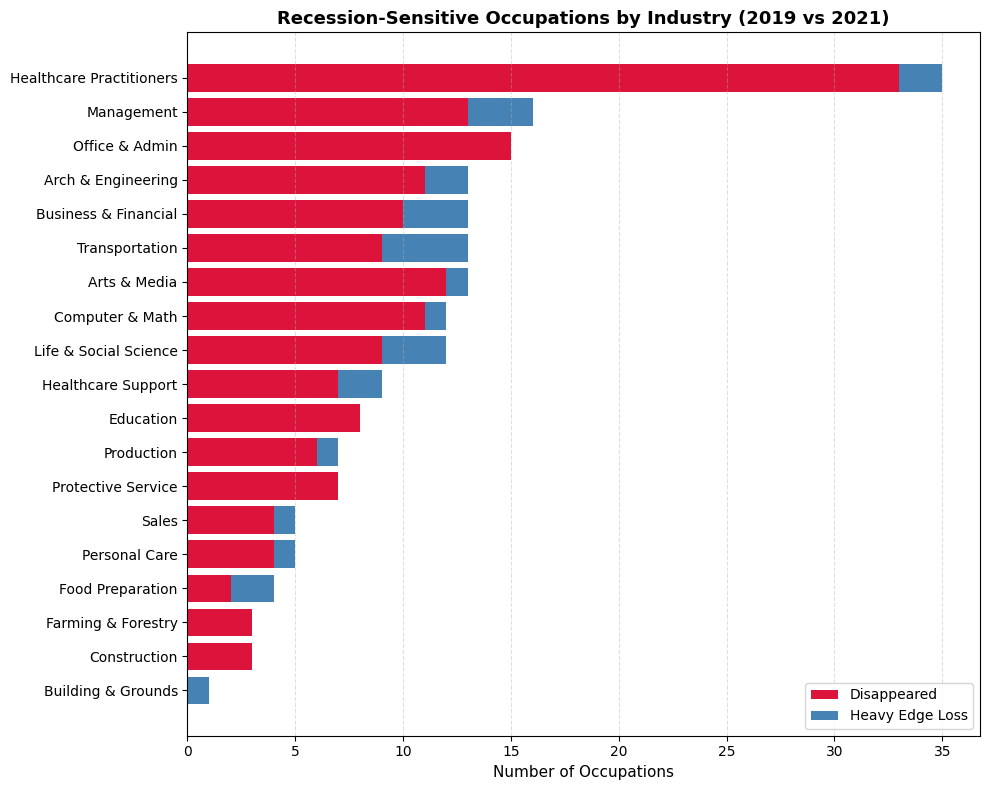

In [16]:
# Bar chart of recession-sensitive occupations by SOC group
# Dictionary of each occupation code and label (Retrieved from https://www.onetcenter.org/database.html)
soc_labels = {
    "11": "Management", 
    "13": "Business & Financial", 
    "15": "Computer & Math",
    "17": "Arch & Engineering", 
    "19": "Life & Social Science", 
    "21": "Community Service",
    "23": "Legal", 
    "25": "Education", 
    "27": "Arts & Media", 
    "29": "Healthcare Practitioners",
    "31": "Healthcare Support", 
    "33": "Protective Service", 
    "35": "Food Preparation",
    "37": "Building & Grounds", 
    "39": "Personal Care", "41": "Sales",
    "43": "Office & Admin", 
    "45": "Farming & Forestry", 
    "47": "Construction",
    "49": "Installation & Repair", 
    "51": "Production", 
    "53": "Transportation", 
    "55": "Military"
}

# Extract the first two digits of the SOC code to get the major group
recession_df["SOC_Major"] = recession_df["SOC Code"].str[:2]
# Map major group code to its readable industry label
recession_df["SOC_Group"] = recession_df["SOC_Major"].map(soc_labels).fillna("Other")

# Count occupations per industry in each status category
grouped = recession_df.groupby(["SOC_Group", "Status"]).size().unstack(fill_value=0)

# Sort by total affected
grouped["Total"] = grouped.sum(axis=1)
grouped = grouped.sort_values("Total", ascending=True).drop(columns="Total")

fig, ax = plt.subplots(figsize=(10, 8))
colors = {"Disappeared": "crimson", "Heavy Edge Loss": "steelblue"}

# Build a stacked horizontal bar chart
bottom = None
for status in grouped.columns:
    values = grouped[status]
    ax.barh(grouped.index, values, left=bottom, color=colors.get(status, "gray"), label=status)
    bottom = values if bottom is None else bottom + values

ax.set_xlabel("Number of Occupations", fontsize=11)
ax.set_title("Recession-Sensitive Occupations by Industry (2019 vs 2021)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4, axis="x")

plt.tight_layout()
plt.show()

### 8. Percolation Simulation
We take the 2019 network and remove recession-sensitive occupations one by one. At each step we track the LCC size as a fraction of the original network. We also run a random removal baseline for comparison.

In [18]:
# Run targeted removal using recession-sensitive occupations
nodes_to_remove = list(recession_sensitive & set(G_pre.nodes()))
targeted_x, targeted_y = run_targeted_removal(G_pre, nodes_to_remove)

# Convert fractions to actual node counts
total_nodes_2019 = G_pre.number_of_nodes()
targeted_y_nodes = [v * total_nodes_2019 for v in targeted_y]

# Run random removal baseline averaged over 100 trials
random_x, random_y = run_random_removal(G_pre, len(nodes_to_remove), n_trials=100)
random_y_nodes = [v * total_nodes_2019 for v in random_y]

print(f"Recession-sensitive nodes removed: {len(nodes_to_remove)}")
print(f"Fraction of 2019 network removed:  {len(nodes_to_remove) / total_nodes_2019:.2%}")

Recession-sensitive nodes removed: 194
Fraction of 2019 network removed:  35.73%


### 9. Plot Percolation Curve

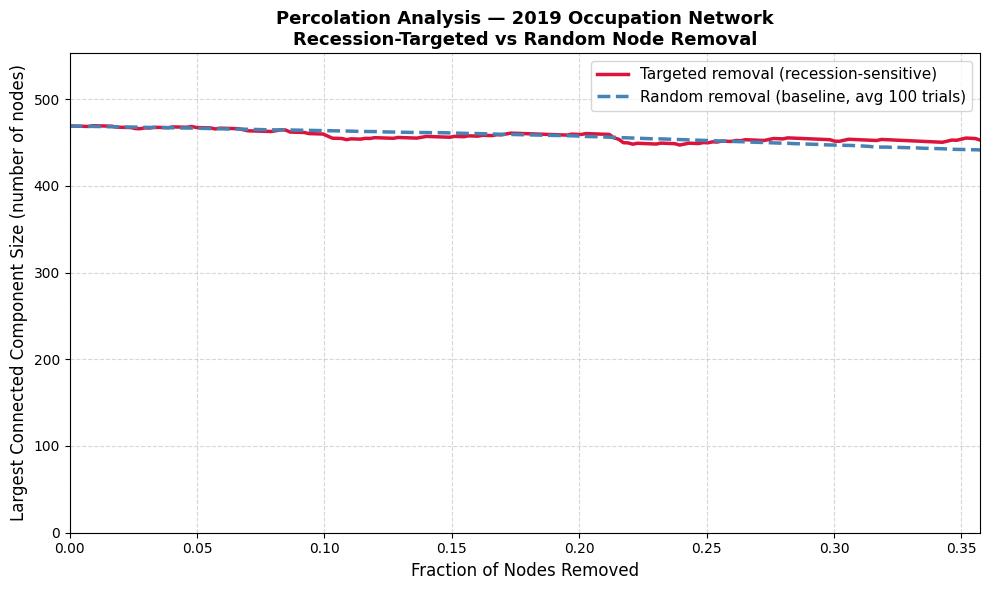

In [19]:
# Plot the percolation curve comparing targeted vs random removal
fig, ax = plt.subplots(figsize=(10, 6))

# Targeted removal — recession-sensitive occupations removed in order
ax.plot(targeted_x, targeted_y_nodes, color="crimson",   linewidth=2.5, label="Targeted removal (recession-sensitive)")
ax.plot(random_x,   random_y_nodes,   color="steelblue", linewidth=2.5, linestyle="--", label="Random removal (baseline, avg 100 trials)")

# Random removal baseline — averaged over 100 independent trials
ax.set_xlabel("Fraction of Nodes Removed", fontsize=12)
ax.set_ylabel("Largest Connected Component Size (number of nodes)", fontsize=12)
ax.set_title("Percolation Analysis — 2019 Occupation Network\nRecession-Targeted vs Random Node Removal", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(0, max(targeted_x))
ax.set_ylim(0, total_nodes_2019 + 10)

plt.tight_layout()
plt.show()

### 10. Track Skill Islands (Isolated Components Over Removal)

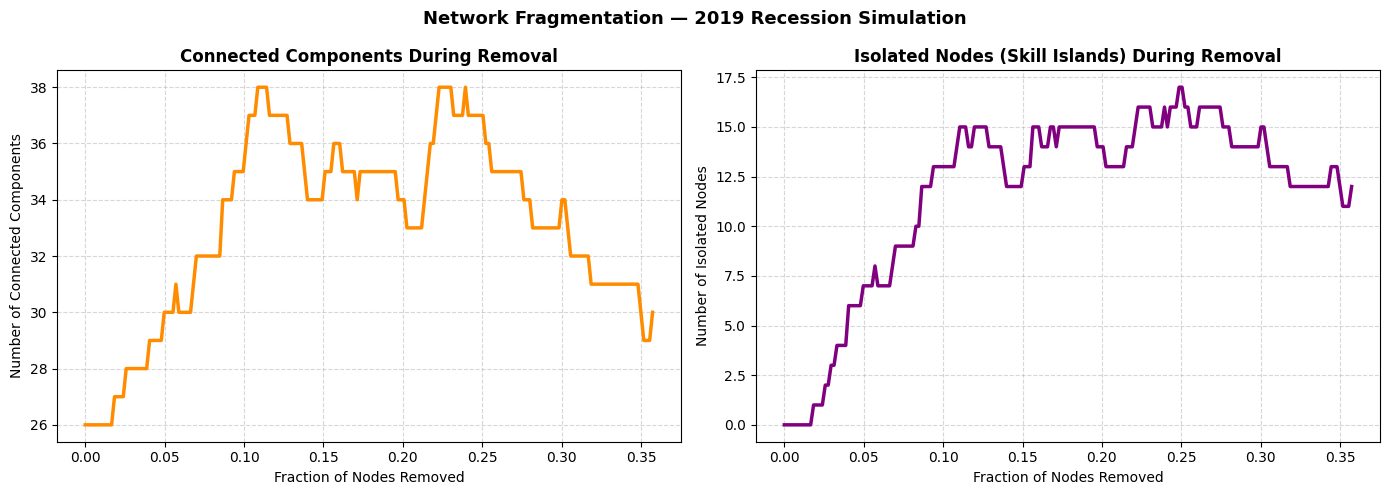

In [20]:
# Run the full fragmentation tracking simulation
removal_df = run_targeted_removal_full(G_pre, nodes_to_remove)

# Plot two side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart — how many connected components form as occupations are removed
axes[0].plot(removal_df["fraction_removed"], removal_df["n_components"], color="darkorange", linewidth=2.5)
axes[0].set_title("Connected Components During Removal", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Fraction of Nodes Removed")
axes[0].set_ylabel("Number of Connected Components")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Right chart — how many completely isolated nodes (skill islands) appear
axes[1].plot(removal_df["fraction_removed"], removal_df["isolated_nodes"], color="purple", linewidth=2.5)
axes[1].set_title("Isolated Nodes (Skill Islands) During Removal", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Fraction of Nodes Removed")
axes[1].set_ylabel("Number of Isolated Nodes")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Network Fragmentation — 2019 Recession Simulation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 11. Summary Table

In [21]:
# Extract key metrics from the removal dataframe for the summary
initial_lcc  = removal_df["lcc_fraction"].iloc[0]
final_lcc    = removal_df["lcc_fraction"].iloc[-1]
max_comp     = removal_df["n_components"].max()
max_isolated = removal_df["isolated_nodes"].max()

# Print a clean summary of the percolation simulation results
print("=== Percolation Simulation Summary ===")
print(f"2019 network nodes:                     {G_pre.number_of_nodes()}")
print(f"Recession-sensitive nodes removed:      {len(nodes_to_remove)}")
print(f"Fraction of network removed:            {len(nodes_to_remove)/G_pre.number_of_nodes():.2%}")
print(f"LCC before removal:                     {initial_lcc:.4f}")
print(f"LCC after removal:                      {final_lcc:.4f}")
print(f"LCC drop:                               {initial_lcc - final_lcc:.4f}")
print(f"Max connected components reached:       {max_comp}")
print(f"Max isolated nodes (skill islands):     {max_isolated}")

=== Percolation Simulation Summary ===
2019 network nodes:                     543
Recession-sensitive nodes removed:      194
Fraction of network removed:            35.73%
LCC before removal:                     0.8637
LCC after removal:                      0.8338
LCC drop:                               0.0299
Max connected components reached:       38
Max isolated nodes (skill islands):     17
